## SciPro ID: 2026SS_07

# Homework_6: Matplotlib/Seaborn and Data Visualization

***

### Imports:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import re

***

## The Dataset:
As the dataset I chose is >30MB I could not provide it over LEA.  
Below is the link at which the dataset can be downloaded and used for this notebook.  
https://www.kaggle.com/datasets/tunguz/200000-jeopardy-questions

***

## Introduction to the Assignment:

The goal of this assignment is to explore a dataset using Pandas, Numpy and Matplotlib, and to communicate the most important findings with clear visualizations.

For this notebook I chose a dataset containing more than 200,000 Jeopardy clues.$^{[1]}$ The analysis focuses on the categories, clue values, rounds and the length of the questions and answers.

A special part of this notebook is the grouping of many individual Jeopardy categories into broader topic groups. Since there are thousands of different category names, this step was supported with ChatGPT.$^{[2]}$

***

## Task 1: Loading and Cleaning the Data

The goal of this task is to prepare the Jeopardy CSV file into a Pandas DataFrame and prepare it for the following visualizations.

The original CSV file contains column names with leading spaces. Therefore, the column names are cleaned first. Rows with missing values and duplicate rows are removes so that the later statistics and plots are based on complete observations.

In [2]:
input_data = pd.read_csv('JEOPARDY_CSV.csv', header=0, sep=',')
input_data.columns = input_data.columns.str.strip()

jeopardy = input_data.dropna().drop_duplicates().copy()

jeopardy

,Show Number,Air Date,Round,Category,Value,Question,Answer
0,4680,2004-12-31,Jeopardy!,HISTORY,$200,"For the last 8 years of his life, Galileo was ...",Copernicus
1,4680,2004-12-31,Jeopardy!,ESPN's TOP 10 ALL-TIME ATHLETES,$200,No. 2: 1912 Olympian; football star at Carlisl...,Jim Thorpe
2,4680,2004-12-31,Jeopardy!,EVERYBODY TALKS ABOUT IT...,$200,The city of Yuma in this state has a record av...,Arizona
3,4680,2004-12-31,Jeopardy!,THE COMPANY LINE,$200,"In 1963, live on ""The Art Linkletter Show"", th...",McDonald's
4,4680,2004-12-31,Jeopardy!,EPITAPHS & TRIBUTES,$200,"Signer of the Dec. of Indep., framer of the Co...",John Adams
...,...,...,...,...,...,...,...
216924,4999,2006-05-11,Double Jeopardy!,OFF-BROADWAY,$2000,In 2006 the cast of this long-running hit emba...,Stomp
216925,4999,2006-05-11,Double Jeopardy!,RIDDLE ME THIS,$2000,This Puccini opera turns on the solution to 3 ...,Turandot
216926,4999,2006-05-11,Double Jeopardy!,"""T"" BIRDS",$2000,In North America this term is properly applied...,a titmouse
216927,4999,2006-05-11,Double Jeopardy!,AUTHORS IN THEIR YOUTH,$2000,"In Penny Lane, where this ""Hellraiser"" grew up...",Clive Barker


The following code gives a short overview of the cleaned dataset. This includes the number of rows and columns, the available column names and the time span of the air dates.

In [3]:
print(f'Rows: {jeopardy.shape[0]}')
print(f'Columns: {jeopardy.shape[1]}')
print(jeopardy.columns.tolist())

jeopardy['Air Date'] = pd.to_datetime(jeopardy['Air Date'])
print(f"First air date: {jeopardy['Air Date'].min().date()}")
print(f"Last air date: {jeopardy['Air Date'].max().date()}")

Rows: 213293
Columns: 7
['Show Number', 'Air Date', 'Round', 'Category', 'Value', 'Question', 'Answer']
First air date: 1984-09-10
Last air date: 2012-01-27


The clue values are stored as text values such as `$200` or `$1,000`. For numerical analysis, the dollar sign and commas are removed and the values are converted into numbers.

In [19]:
jeopardy['Value_Numeric'] = (
    jeopardy['Value']
    .str.replace('$', '')
    .str.replace(',', '')
)

jeopardy['Value_Numeric'] = pd.to_numeric(jeopardy['Value_Numeric'], errors='coerce')
jeopardy['Year'] = jeopardy['Air Date'].dt.year

jeopardy[['Value', 'Value_Numeric']]

,Value,Value_Numeric
0,$200,200
1,$200,200
2,$200,200
3,$200,200
4,$200,200
...,...,...
216924,$2000,2000
216925,$2000,2000
216926,$2000,2000
216927,$2000,2000


Two additional columns are created to measure the length of a clue and the length of the correct answer. This makes it possible to compare text length with clue value later.

In [5]:
jeopardy['Question_Word_Count'] = jeopardy['Question'].str.split().str.len()
jeopardy['Answer_Word_Count'] = jeopardy['Answer'].str.split().str.len()

jeopardy[['Question', 'Question_Word_Count', 'Answer', 'Answer_Word_Count']]

,Question,Question_Word_Count,Answer,Answer_Word_Count
0,"For the last 8 years of his life, Galileo was ...",18,Copernicus,1
1,No. 2: 1912 Olympian; football star at Carlisl...,19,Jim Thorpe,2
2,The city of Yuma in this state has a record av...,18,Arizona,1
3,"In 1963, live on ""The Art Linkletter Show"", th...",14,McDonald's,1
4,"Signer of the Dec. of Indep., framer of the Co...",18,John Adams,2
...,...,...,...,...
216924,In 2006 the cast of this long-running hit emba...,22,Stomp,1
216925,This Puccini opera turns on the solution to 3 ...,14,Turandot,1
216926,In North America this term is properly applied...,18,a titmouse,2
216927,"In Penny Lane, where this ""Hellraiser"" grew up...",16,Clive Barker,2


***

## Task 2: Most Common Jeopardy Categories

The goal of this task is to find out which Jeopardy categories appear most often in the dataset.

Only the 20 most common categories are plotted. Plotting every category would make the chart unreadable, because the dataset contains thousands of different category names.

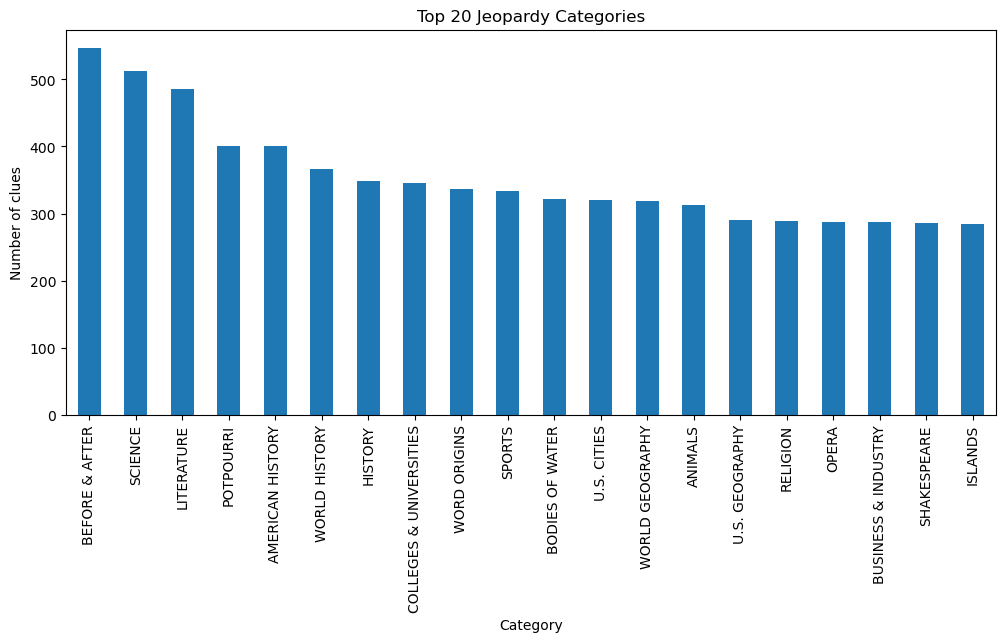

In [6]:
category_counts = jeopardy['Category'].value_counts()

category_counts.head(20).plot(
    kind='bar',
    xlabel='Category',
    ylabel='Number of clues',
    title='Top 20 Jeopardy Categories',
    figsize=(12, 5),
    fontsize=10
)

plt.show()

The chart shows that some categories appear much more often than others. Howevey, many Jeopardy categories are only used a small number of times. This can be seen more clearly with a histogram of the category frequencies.

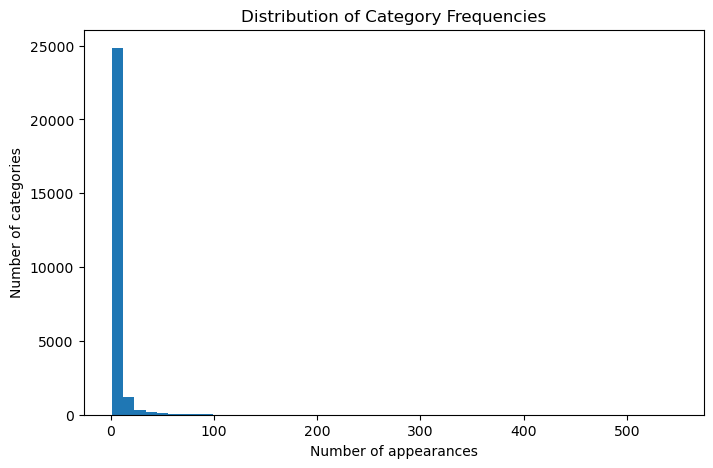

In [7]:
category_counts.plot(
    kind='hist',
    bins=50,
    xlabel='Number of appearances',
    ylabel='Number of categories',
    title='Distribution of Category Frequencies',
    figsize=(8, 5)
)

plt.show()

The histogram shows a long-tail distribution.$^{[3]}$  
This means that most of the categories appear very few times, while some few categories appear more often.

***

## Task 3: Topic Grouping of Categories

The goal of this task is to group the many detailed Jeopardy categories into broader topic groups such as `History & Politics`, `Science & Nature` or `Arts & Entertainment`.

This step was supported by ChatGPT. First, the `category` column was exported into a seperate CSV file. This file was uploaded to ChatGPT so that broad topic groups and useful keywords could be suggested.$^{[2]}$ The usage of generative AI for this task was allowed by Dr. Karl Kischner.

The final function below was still made by a human. It also does not use machine learning. Instead, it checks whether certain keywords appear in a category name. This makes the method easy to understand, but also imperfect. Some categories are puns or mixed topics, so they are placed into `Other & Mixed` when no clear keyword match is found.

In [8]:
#jeopardy[['Category']].to_csv('Jeopardy_Categories', sep=',',
#                             index=False, encoding='utf-8')

The keyword dictionary contains the broad topic groups and the keywords that are used to identify them.

In [9]:
TOPIC_KEYWORDS = {
    'Wordplay & Language': [
        'WORD', 'WORDS', 'LETTER', 'LETTERS', 'RHYME', 'RHYMES', 'ANAGRAM',
        'HOMOPHONE', 'PREFIX', 'SUFFIX', 'VOWEL', 'CONSONANT',
        'BEFORE AND AFTER', 'COMMON BONDS', 'STUPID ANSWERS',
        'QUOTE', 'QUOTES', 'QUOTATION', 'PHRASE', 'IDIOM',
        'LANGUAGE', 'LANGUAGES', 'DICTIONARY', 'VOCABULARY',
        'ABBREVIATION', 'PROVERB', 'CROSSWORD', 'SYMBOL', 'LATIN', 'GREEK'
    ],

    'History & Politics': [
        'HISTORY', 'HISTORICAL', 'HISTORIC', 'WAR', 'MILITARY',
        'PRESIDENT', 'PRESIDENTS', 'KING', 'KINGS', 'QUEEN', 'QUEENS',
        'ROYAL', 'EMPIRE', 'REVOLUTION', 'BATTLE', 'GOVERNMENT',
        'POLITICS', 'POLITICAL', 'CONGRESS', 'SENATE', 'CABINET',
        'ELECTION', 'ANCIENT', 'MEDIEVAL', 'CENTURY', 'DECADE'
    ],

    'Geography & Places': [
        'GEOGRAPHY', 'COUNTRY', 'COUNTRIES', 'CITY', 'CITIES',
        'STATE', 'STATES', 'CAPITAL', 'CAPITALS', 'ISLAND', 'ISLANDS',
        'RIVER', 'RIVERS', 'LAKE', 'LAKES', 'WATER', 'MOUNTAIN',
        'MOUNTAINS', 'OCEAN', 'SEA', 'AFRICA', 'ASIA', 'EUROPE',
        'AMERICA', 'CANADA', 'MEXICO', 'WORLD', 'TRAVEL', 'LANDMARK'
    ],

    'Science & Nature': [
        'SCIENCE', 'SCIENTIST', 'NATURE', 'BIOLOGY', 'CHEMISTRY',
        'PHYSICS', 'ASTRONOMY', 'SPACE', 'PLANET', 'ANIMAL', 'ANIMALS',
        'BIRD', 'FISH', 'PLANT', 'TREE', 'FLOWER', 'DINOSAUR',
        'MEDICINE', 'MEDICAL', 'BODY', 'HEALTH', 'MATH', 'WEATHER',
        'ZOOLOGY', 'ANATOMY', 'BOTANY', 'GEOLOGY', 'ELEMENT'
    ],

    'Literature & Books': [
        'LITERATURE', 'LITERARY', 'LIT', 'BOOK', 'BOOKS', 'AUTHOR',
        'AUTHORS', 'NOVEL', 'NOVELS', 'NONFICTION', 'POET', 'POETS',
        'POETRY', 'SHAKESPEARE', 'FICTION', 'FICTIONAL', 'CHARACTER',
        'CHARACTERS', 'STORY', 'LIBRARY', 'PLAYWRIGHT'
    ],

    'Arts & Entertainment': [
        'MOVIE', 'MOVIES', 'FILM', 'FILMS', 'CINEMA', 'TV', 'TELEVISION',
        'MUSIC', 'MUSICAL', 'SONG', 'SONGS', 'OPERA', 'BALLET',
        'THEATER', 'THEATRE', 'BROADWAY', 'ACTOR', 'ACTRESS', 'DIRECTOR',
        'ART', 'ARTIST', 'PAINTING', 'MUSEUM', 'HOLLYWOOD', 'CELEBRITY',
        'OSCAR', 'POP', 'ROCK', 'BAND', 'COMPOSER', 'SINGER', 'FASHION'
    ],

    'Sports & Games': [
        'SPORT', 'SPORTS', 'BASEBALL', 'FOOTBALL', 'BASKETBALL',
        'SOCCER', 'TENNIS', 'GOLF', 'OLYMPIC', 'OLYMPICS',
        'ATHLETE', 'ATHLETES', 'TEAM', 'TEAMS', 'GAME', 'GAMES',
        'PLAYER', 'PLAYERS'
    ],

    'Religion & Mythology': [
        'RELIGION', 'BIBLE', 'BIBLICAL', 'GOD', 'GODS', 'GODDESS',
        'MYTH', 'MYTHS', 'MYTHOLOGY', 'CHURCH', 'SAINT', 'POPE', 'TESTAMENT'
    ],

    'Food & Drink': [
        'FOOD', 'DRINK', 'DRINKS', 'COOK', 'COOKING', 'CUISINE',
        'RESTAURANT', 'FRUIT', 'VEGETABLE', 'HERB', 'SPICE',
        'MEAT', 'CHEESE', 'WINE', 'BEER', 'COFFEE', 'TEA', 'DESSERT'
    ],

    'Business, Tech & Transport': [
        'BUSINESS', 'INDUSTRY', 'COMPANY', 'COMPANIES', 'BRAND',
        'MONEY', 'ECONOMICS', 'INVENTION', 'INVENTOR', 'TECH',
        'TECHNOLOGY', 'COMPUTER', 'INTERNET', 'TRANSPORTATION',
        'AVIATION', 'CAR', 'CARS', 'AUTO', 'TRAIN', 'PLANE', 'SHIP'
    ],

    'People & Society': [
        'PEOPLE', 'PERSON', 'NAME', 'NAMES', 'FAMOUS', 'BIOGRAPHY',
        'FAMILY', 'FATHER', 'MOTHER', 'CHILD', 'CHILDREN', 'WOMEN',
        'MEN', 'COLLEGE', 'UNIVERSITY', 'SCHOOL', 'EDUCATION',
        'JOB', 'HOLIDAY', 'LAW', 'LEGAL', 'PHILOSOPHY'
    ]
}

The helper function first standardizes the category text. The main categorization function then searches the cleaned text for the keywords above and returns the first matching topic group.

In [20]:
def clean_category_text(category: str) -> str:
    '''Cleans a Jeopardy category string for keyword matching.

        Args: category name as a string.

        Returns: String of cleaned Category name.

        Raises: TypeError if Category name is not a String.    
    '''
    if not isinstance(category, str):
        raise TypeError(f'The value used for Category in '
                        f'clean_category_text:'
                        f'{category} is not a valid String.')
    
    text = str(category).upper()
    text = text.replace('&', ' AND ')
    text = re.sub(r'[^A-Z0-9]+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text


def categorize_category(category: str) -> str:
    '''Assigns a broad topic group to a Jeopardy category.

        Args: Category name as a string.

        Returns: Grouped topic name for category input.

        Raises: TypeError if Category name is not a String.
    '''
    if not isinstance(category, str):
        raise TypeError(f'The value used for Category in '
                        f'categorize_category: '
                        f'{category} is not a valid String.')
    
    text = clean_category_text(category)

    for topic, keywords in TOPIC_KEYWORDS.items():
        for keyword in keywords:
            pattern = r'\b' + re.escape(keyword) + r'\b'

            if re.search(pattern, text):
                return topic

    return 'Other / Mixed'

The function is then applied to every Jeopardy category in the dataset. The result is then stored in a new column: `Topic_Group`.  
Be aware running the cell below may take a while, up to 5 minutes.

In [21]:
jeopardy['Topic_Group'] = jeopardy['Category'].apply(categorize_category)

jeopardy[['Category', 'Topic_Group']].head(10)

,Category,Topic_Group
0,HISTORY,History & Politics
1,ESPN's TOP 10 ALL-TIME ATHLETES,Sports & Games
2,EVERYBODY TALKS ABOUT IT...,Other / Mixed
3,THE COMPANY LINE,"Business, Tech & Transport"
4,EPITAPHS & TRIBUTES,Other / Mixed
5,3-LETTER WORDS,Wordplay & Language
6,HISTORY,History & Politics
7,ESPN's TOP 10 ALL-TIME ATHLETES,Sports & Games
8,EVERYBODY TALKS ABOUT IT...,Other / Mixed
9,THE COMPANY LINE,"Business, Tech & Transport"


The following chart shows the number of clues per topic group.

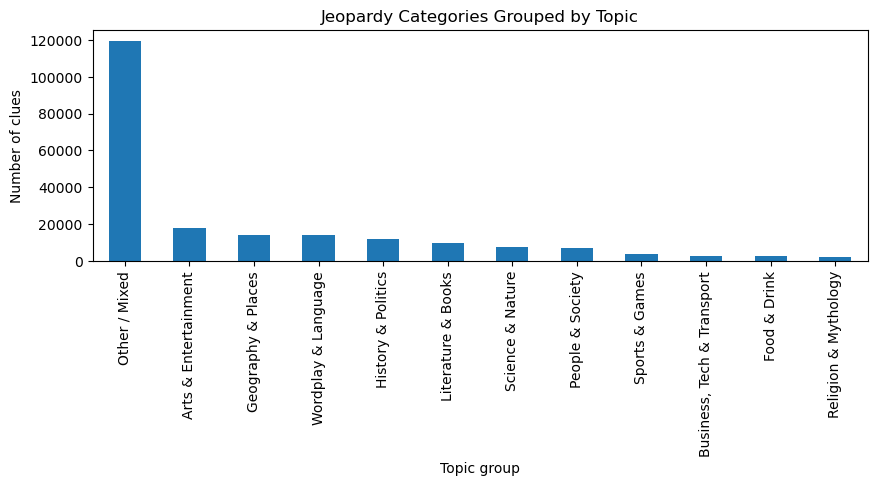

In [12]:
topic_counts = jeopardy['Topic_Group'].value_counts()

topic_counts.plot(
    kind='bar',
    xlabel='Topic group',
    ylabel='Number of clues',
    title='Jeopardy Categories Grouped by Topic',
    figsize=(10, 3),
    fontsize=10
)

plt.show()

Now if we exclude `Other / Mixed` because it contains unclear, mixed or pun-based categories that do not fit into one of the selected topic groups. We get a clearer view of the data.

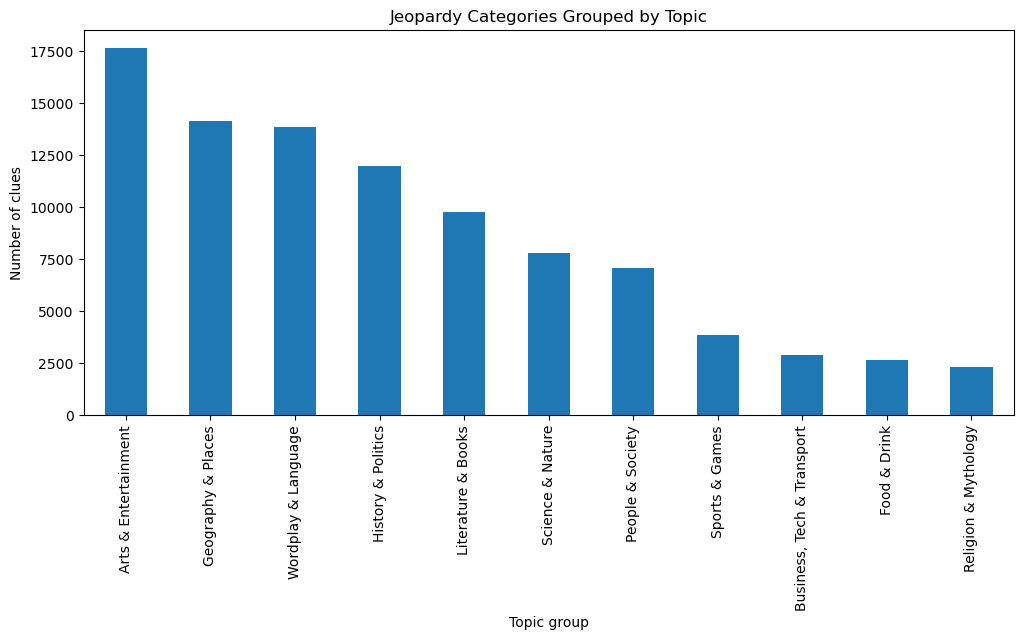

In [13]:
topic_counts_without_other = topic_counts.drop('Other / Mixed', errors='ignore')

topic_counts_without_other.plot(
    kind='bar',
    xlabel='Topic group',
    ylabel='Number of clues',
    title='Jeopardy Categories Grouped by Topic',
    figsize=(12, 5),
    fontsize=10
)

plt.show()

This grouped view is less detailed than the original category names, but it makes the dataset easier to compare. 
It shows that `Arts & Entertainment` is the favored category, however it also shows that Jeopardy contains a wide mixture of knowledge areas instead of only one dominant subject.

***

## Task 4: Round and Value Analysis

The goal of this task is to compare the different Jeopardy rounds and to analyze the clue values.

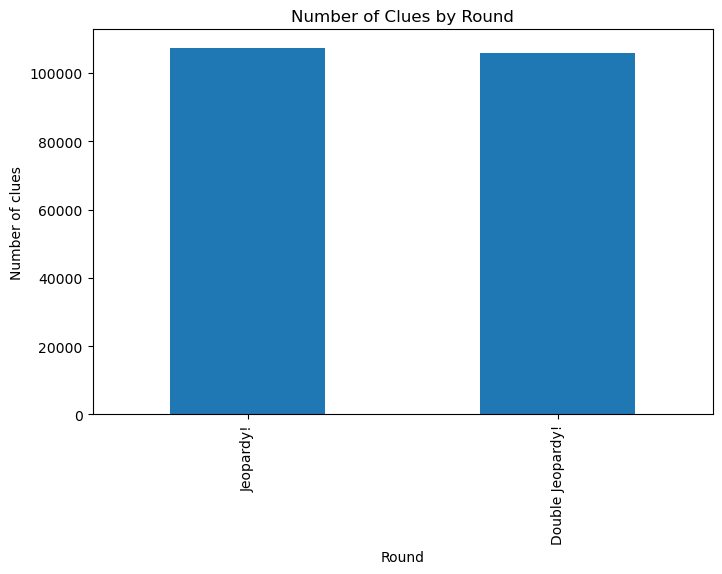

In [14]:
jeopardy['Round'].value_counts().plot(
    kind='bar',
    xlabel='Round',
    ylabel='Number of clues',
    title='Number of Clues by Round',
    figsize=(8, 5)
)

plt.show()

The next visualization compares the average clue value by round. Final Jeopardy clues are removed during the cleaning step because they do not have a regular fixed dollar value.

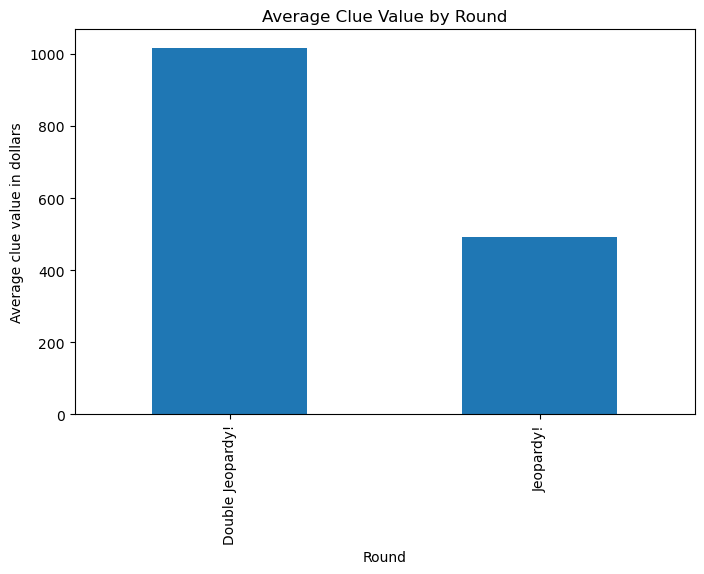

In [15]:
average_value_by_round = jeopardy.groupby('Round')['Value_Numeric'].mean()

average_value_by_round.plot(
    kind='bar',
    xlabel='Round',
    ylabel='Average clue value in dollars',
    title='Average Clue Value by Round',
    figsize=(8, 5)
)

plt.show()

As expected, `Double Jeopardy!` has a higher average clue value, about double as much, than the first `Jeopardy!` round because the fixed clue values are larger in that round.

***

## Task 5: Question and Answer Length

The goal of this task is to check whether the length of the question or answer is connected to the clue value.

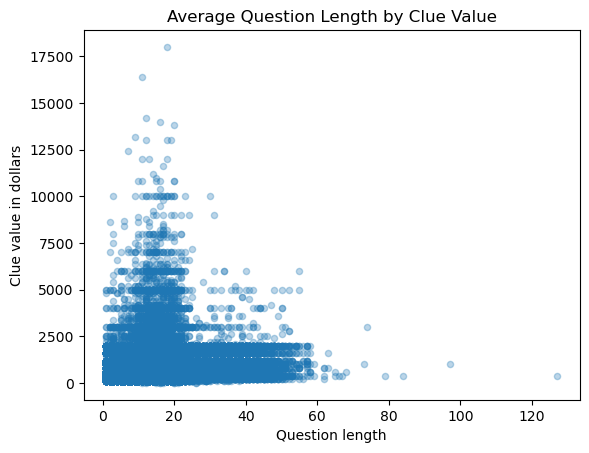

In [17]:
jeopardy.plot(
    x='Question_Word_Count',
    xlabel='Question length',
    y='Value_Numeric',
    ylabel='Clue value in dollars',
    kind='scatter',
    alpha=0.3,
    title='Average Question Length by Clue Value'
)

plt.show()

This plot shows, that higher-value clues do not have to correlate to a longer worded question. In fact, this also objectively means that Question length alone is not the same as difficulty.

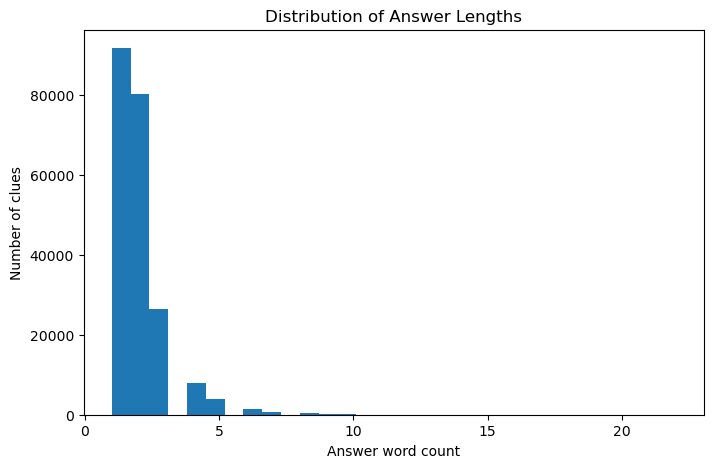

In [18]:
jeopardy['Answer_Word_Count'].plot(
    kind='hist',
    bins=30,
    xlabel='Answer word count',
    ylabel='Number of clues',
    title='Distribution of Answer Lengths',
    figsize=(8, 5)
)

plt.show()

Most Jeopardy answers are short. This fits the structure of the game, because contestants usually respond with a short name, place, title or phrase.

***

## Summary of Results and Interpretation

The analysis shows that Jeopardy categories have a long-tail distribution. A few categories, such as common history, science or literature categories, appear very often, while many categories appear only a small handful of times.

The topic grouping makes the large number of category names easier to analyze. The grouped topic chart shows that Jeopardy covers many different knowledge areas. However, the classification is not perfect as a lot of sub categories were excluded due to them being jokes, puns or mixed topics. 

The round and value analysis shows the expected difference between `Jeopardy!` and `Double Jeopardy!`, with higher average values in the second round. The text-length plots suggest that clue and answer length can be measured, but length alone does not fully describe clue difficulty.

***

## References:

[1] Tunguz. (n.d.). *200,000+ Jeopardy! Questions*. Kaggle. https://www.kaggle.com/datasets/tunguz/200000-jeopardy-questions. Accessed on July 4, 2026.

[2] OpenAI. (2026). *ChatGPT, GPT-5.5*. Used to support the creation of the keyword-based topic grouping after uploading the exported Jeopardy category list `Jeopardy_Categories.csv`. Accessed on July 4, 2026.

[3] Wikipedia contributors, ”Long Tail.” Wikimedia Foundation. Last modified June 26, 2026. https://en.wikipedia.org/wiki/Long_tail Last access on July 5, 2026.